Possibilities 			 F(sampling kHz) 			 F(clock MHz)
256 				 44.1 					 11.2896
256 				 48 					 12.288
256 				 88.2 					 22.5792
256 				 96 					 24.576
256 				 176.4 					 45.1584
256 				 192 					 49.152
256 				 200 					 51.2
256 				 216 					 55.296
256 				 220 					 56.32
256 				 225 					 57.6
256 				 250 					 64.0
256 				 333 					 85.248
256 				 384 					 98.304
4096 				 44.1 					 180.6336
4096 				 48 					 196.608
4096 				 88.2 					 361.2672
4096 				 96 					 393.216
4096 				 176.4 					 722.5344
4096 				 192 					 786.432
4096 				 200 					 819.2
4096 				 216 					 884.736
4096 				 220 					 901.12
4096 				 225 					 921.6
4096 				 250 					 1024.0
4096 				 333 					 1363.968
4096 				 384 					 1572.864
16384 				 44.1 					 722.5344
16384 				 48 					 786.432
16384 				 88.2 					 1445.0688
16384 				 96 					 1572.864
16384 				 176.4 					 2890.1376
16384 				 192 					 3145.728
16384 				 200 					 3276.8
16384 				 216 					 3538.944
16384 	

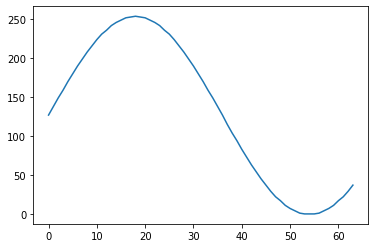

Minimum value is: 0
Maximum value is: 254
[127 138 149 159 170 180 190 199 208 216 224 231 236 242 246 249 252 253
 254 253 252 249 246 242 236 231 224 216 208 199 190 180 170 159 149 138
 127 115 104  94  83  73  63  54  45  37  29  22  17  11   7   4   1   0
   0   0   1   4   7  11  17  22  29  37]
0 : pwm_dc <= 'b01111111;
1 : pwm_dc <= 'b10001010;
2 : pwm_dc <= 'b10010101;
3 : pwm_dc <= 'b10011111;
4 : pwm_dc <= 'b10101010;
5 : pwm_dc <= 'b10110100;
6 : pwm_dc <= 'b10111110;
7 : pwm_dc <= 'b11000111;
8 : pwm_dc <= 'b11010000;
9 : pwm_dc <= 'b11011000;
10 : pwm_dc <= 'b11100000;
11 : pwm_dc <= 'b11100111;
12 : pwm_dc <= 'b11101100;
13 : pwm_dc <= 'b11110010;
14 : pwm_dc <= 'b11110110;
15 : pwm_dc <= 'b11111001;
16 : pwm_dc <= 'b11111100;
17 : pwm_dc <= 'b11111101;
18 : pwm_dc <= 'b11111110;
19 : pwm_dc <= 'b11111101;
20 : pwm_dc <= 'b11111100;
21 : pwm_dc <= 'b11111001;
22 : pwm_dc <= 'b11110110;
23 : pwm_dc <= 'b11110010;
24 : pwm_dc <= 'b11101100;
25 : pwm_dc <= 'b11100111;
26 : 

In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt

def f_samp_to_clk():
    n_bits = [8, 12, 14, 16, 18, 20, 24, 32]
    f_samp = [44.1, 48, 88.2, 96, 176.4, 192, 200, 216, 220, 225, 250, 333, 384]
    f_clk = []
    print("Possibilities \t\t\t F(sampling kHz) \t\t\t F(clock MHz)")
    for j in range(len(n_bits)):
        for i in range(len(f_samp)):
            f_clk = f_samp[i]*2**(n_bits[j])*1000
            print("{} \t\t\t\t {} \t\t\t\t\t {}".format(2**(n_bits[j]), f_samp[i], f_clk/1000000))

def sine_to_binary():
    amp = np.sin(np.array(range(0,360,5)) * np.pi / 180. )
    amp = amp+1
    amp = amp*(2**(7)-1)
    amp = amp.astype(int)
    amp_bin = amp[0:63+1]
    plt.plot(amp_bin)
    plt.show()
    print("Minimum value is: {}".format(min(amp_bin)))
    print("Maximum value is: {}".format(max(amp_bin)))
    print(amp_bin)
    for i in range(len(amp_bin)):
        print("{} : pwm_dc <= 'b{};".format(i, np.binary_repr(amp_bin[i], width=8)))

f_samp_to_clk()
sine_to_binary()

In [4]:
##PDM to PCM

import numpy as np
from scipy import signal

#“”"
#Step 1: Preprocessing
#In this step, we first convert the 32-bit integer buffer to 16-bit.
#Then we divide 16-bit words (16 1-bit samples each) into 8-bit words with 1-bit sample each.
#“”"
def preprocess(audio_buffer):

af_uint8 = np.unpackbits(audio_buffer.astype(np.int16).byteswap(True).view(np.uint8))
return af_uint8

IndentationError: expected an indented block (488447485.py, line 13)